In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [190]:
df = pd.read_csv('data kotor\job_salary_prediction_dataset.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\j'
<>:1: SyntaxWarning: invalid escape sequence '\j'
C:\Users\HP\AppData\Local\Temp\ipykernel_16136\2069195154.py:1: SyntaxWarning: invalid escape sequence '\j'
  df = pd.read_csv('data kotor\job_salary_prediction_dataset.csv')


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [191]:
df.info(),df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


(None, (250000, 10))

In [192]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [193]:
df.isna().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [194]:
df.duplicated().sum()

np.int64(0)

<Axes: ylabel='salary'>

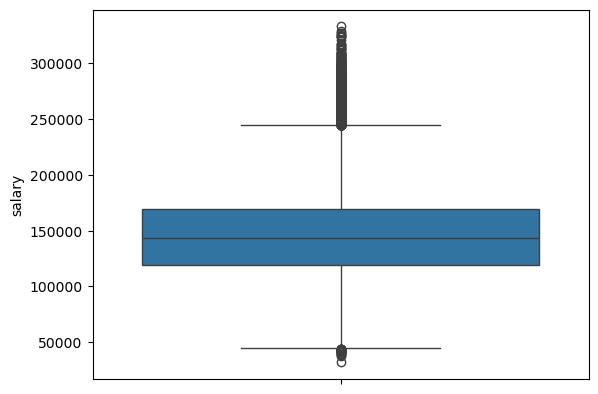

In [195]:
df_num = df.select_dtypes(include=[np.number])
sns.boxplot(df_num['salary'])

In [196]:
quartiles = df_num.quantile([0, 0.25, 0.5, 0.75, 1.0])
quartiles.index = ["minimum","Q1","median","Q3","Maximum"]

print(quartiles)

         experience_years  skills_count  certifications    salary
minimum               0.0           1.0             0.0   31867.0
Q1                    5.0           5.0             1.0  119358.0
median               10.0          10.0             2.0  143453.0
Q3                   15.0          15.0             4.0  169492.0
Maximum              20.0          19.0             5.0  333046.0


In [197]:
IQR = quartiles.loc['Q3']-quartiles.loc['Q1']
lower_fence = quartiles.loc['Q1']-1.5*(IQR)
higher_fence = quartiles.loc['Q3']+1.5*(IQR)

print("\nIQR:",IQR)
print("\nbatas bawah: ",lower_fence)
print("\nbatas atas: ",higher_fence)


IQR: experience_years       10.0
skills_count           10.0
certifications          3.0
salary              50134.0
dtype: float64

batas bawah:  experience_years      -10.0
skills_count          -10.0
certifications         -3.5
salary              44157.0
dtype: float64

batas atas:  experience_years        30.0
skills_count            30.0
certifications           8.5
salary              244693.0
dtype: float64


In [198]:
df_num = df.select_dtypes(include=[np.number])
outliers_index = df[((df_num < lower_fence) | (df_num > higher_fence)).any(axis=1)].index
df = df.drop(outliers_index)


C:\Users\HP\AppData\Local\Temp\ipykernel_16136\2222863407.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend() # Menampilkan label


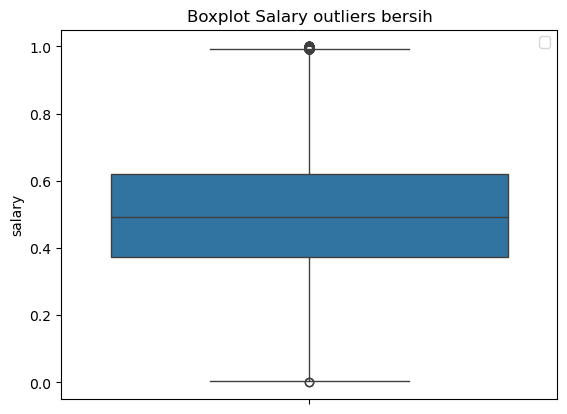

In [226]:
sns.boxplot(df['salary'])
plt.title('Boxplot Salary outliers bersih')
plt.legend() # Menampilkan label
plt.show()

In [200]:
for col in df_num.columns:
    outlier = df[
        (df[col] < lower_fence[col]) |
        (df[col] > higher_fence[col])
    ]
    print(f"{col}: {len(outlier)} outlier")

experience_years: 0 outlier
skills_count: 0 outlier
certifications: 0 outlier
salary: 0 outlier


In [201]:
df.head(5)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [202]:
df_str = df.select_dtypes(include=['object'])
for col in df_str.columns:
    print(f"nilai unik kolom: {col}")
    print(df_str[col].unique())
    print("-"*70)

nilai unik kolom: job_title
['AI Engineer' 'Data Analyst' 'Frontend Developer' 'Business Analyst'
 'Product Manager' 'Backend Developer' 'Machine Learning Engineer'
 'DevOps Engineer' 'Software Engineer' 'Cybersecurity Analyst'
 'Data Scientist' 'Cloud Engineer']
----------------------------------------------------------------------
nilai unik kolom: education_level
['Bachelor' 'PhD' 'High School' 'Diploma' 'Master']
----------------------------------------------------------------------
nilai unik kolom: industry
['Healthcare' 'Telecom' 'Media' 'Retail' 'Manufacturing' 'Education'
 'Finance' 'Technology' 'Consulting' 'Government']
----------------------------------------------------------------------
nilai unik kolom: company_size
['Medium' 'Small' 'Large' 'Enterprise' 'Startup']
----------------------------------------------------------------------
nilai unik kolom: location
['India' 'Australia' 'Singapore' 'Canada' 'Sweden' 'USA' 'Netherlands'
 'Remote' 'Germany' 'UK']
--------------

In [203]:
#label encoding (kategori setara/nominal)
df_nominal = df[['industry','location','remote_work']]

In [204]:
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
encoder = OneHotEncoder(sparse_output=False)

In [205]:
encoded = encoder.fit_transform(df[df_nominal.columns])
encoder_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(),index=df.index)
encoder_df.head(5)

,industry_Consulting,industry_Education,industry_Finance,industry_Government,industry_Healthcare,industry_Manufacturing,industry_Media,industry_Retail,industry_Technology,industry_Telecom,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [206]:
df = pd.concat([df,encoder_df],axis=1)


In [207]:
try:
    df= df.drop(columns=df_nominal.columns,axis=1)
except:
    print("Error: Kolom tidak ditemukan atau sudah dihapus.")
    df

In [208]:
df.head(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,10,Bachelor,2,Medium,2,109413,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,5,Bachelor,17,Small,0,93764,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,18,PhD,4,Medium,1,148123,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,19,PhD,13,Medium,0,189123,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,15,Bachelor,7,Large,0,165069,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [209]:
# mengolah data oridnal
df_ordinal = df[['education_level','company_size']]
df_ordinal.head(5)


,education_level,company_size
0,Bachelor,Medium
1,Bachelor,Small
2,PhD,Medium
3,PhD,Medium
4,Bachelor,Large


In [210]:
encoder = OrdinalEncoder()

In [211]:
encoded = encoder.fit_transform(df[df_ordinal.columns])
df[df_ordinal.columns]= encoded
df.tail(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
249995,Software Engineer,17,4.0,2,0.0,1,127791,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249996,Frontend Developer,20,4.0,7,4.0,2,154593,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
249997,Business Analyst,1,0.0,12,0.0,0,75988,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
249998,Data Scientist,0,2.0,2,3.0,5,90467,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
249999,Data Analyst,16,1.0,2,2.0,5,133084,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [212]:
#normalisasi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_normal = df[['experience_years','skills_count','salary']]

In [213]:
normal = scaler.fit_transform(df[df_normal.columns])
df[df_normal.columns] = normal
df.head(5)

,job_title,experience_years,education_level,skills_count,company_size,certifications,salary,industry_Consulting,industry_Education,industry_Finance,...,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_Hybrid,remote_work_No,remote_work_Yes
0,AI Engineer,0.50,0.0,0.055556,2.0,2,0.324620,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Data Analyst,0.25,0.0,0.888889,3.0,0,0.246491,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Frontend Developer,0.90,4.0,0.166667,2.0,1,0.517881,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Business Analyst,0.95,4.0,0.666667,2.0,0,0.722575,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,Product Manager,0.75,0.0,0.333333,1.0,0,0.602484,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [214]:
#save data
# df.to_csv("data bersih/Job_Salary_Cleaning.csv",index=False)